In [2]:
import pandas as pd
path = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/modelled_yield/past_yield/'
state ='NSW'
filename = f'all_states_modelled_annual_avg_yield.csv'
df = pd.read_csv(path + filename)
df

,state,year,predicted_yield
0,AUS,1951,0.471014
1,AUS,1952,0.307101
2,AUS,1953,0.417743
3,AUS,1954,0.090775
4,AUS,1955,-0.046107
...,...,...,...
421,WA,2017,0.288674
422,WA,2018,-0.153039
423,WA,2019,0.097503
424,WA,2020,-0.588436


,year,lat,lon,state,predicted_yield
0,2022,-38.30,143.85,VIC,0.384964
1,2022,-38.25,143.85,VIC,0.400026
2,2022,-38.25,143.90,VIC,0.421641
3,2022,-38.20,143.90,VIC,0.244285
4,2022,-38.20,143.95,VIC,0.195332
...,...,...,...,...,...
2830,2022,-34.25,141.80,VIC,0.616267
2831,2022,-34.25,141.85,VIC,0.666769
2832,2022,-34.25,141.90,VIC,0.677896
2833,2022,-34.25,141.95,VIC,0.729971


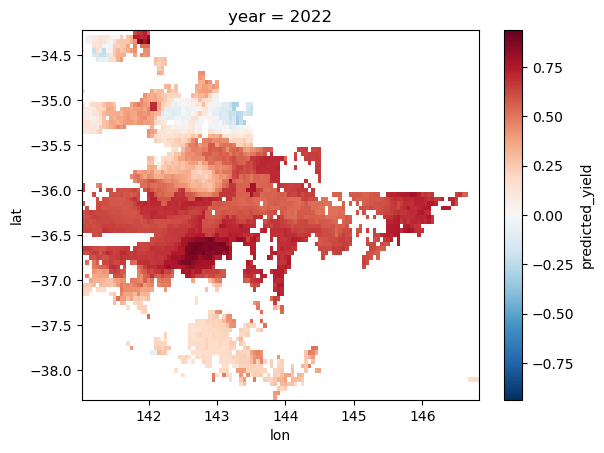

In [20]:
path = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/modelled_yield/past_yield/'
file = 'VIC_modelled_yield_2022-2025.csv'
import pandas as pd
df = pd.read_csv(path + file)
df_2022 = df[df['year'] == 2022]
df_2023 = df[df['year'] == 2023]

da_2022 = df_2022[['year', 'lat', 'lon', 'predicted_yield']].set_index(['year', 'lat', 'lon']).to_xarray()
da_2022['predicted_yield'].plot()
df_2022

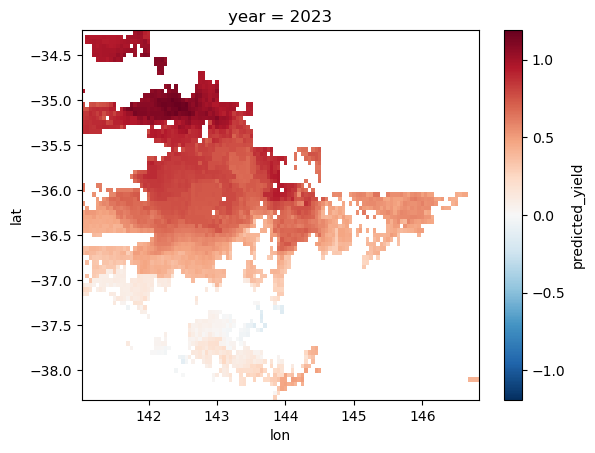

In [16]:
da_2023 = df_2023[['year', 'lat', 'lon', 'predicted_yield']].set_index(['year', 'lat', 'lon']).to_xarray()
da_2023['predicted_yield'].plot()

In [19]:
path = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/modelled_yield/past_yield/'
file = 'VIC_modelled_yield.csv'
df = pd.read_csv(path + file)
df_2019 = df[df['year'] == 2019]
# df_2023 = df[df['year'] == 2023]

da_2019 = df_2019[['year', 'lat', 'lon', 'predicted_yield']].set_index(['year', 'lat', 'lon']).to_xarray()
da_2019#['predicted_yield'].plot()
df_2019

,year,lat,lon,state,predicted_yield
192780,2019,-38.30,143.85,VIC,0.222526
192781,2019,-38.25,143.85,VIC,0.161064
192782,2019,-38.25,143.90,VIC,0.133246
192783,2019,-38.20,143.90,VIC,0.010214
192784,2019,-38.20,143.95,VIC,0.152594
...,...,...,...,...,...
195610,2019,-34.25,141.80,VIC,-0.259535
195611,2019,-34.25,141.85,VIC,-0.244972
195612,2019,-34.25,141.90,VIC,-0.282069
195613,2019,-34.25,141.95,VIC,-0.372343


<Axes: xlabel='year'>

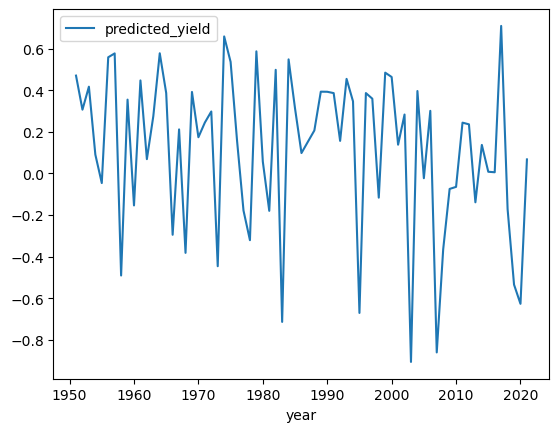

In [4]:
aus_df = df[df['state'] == 'AUS']
aus_df.plot(x='year', y='predicted_yield')

In [47]:
import xarray as xr

path = '/g/data/w97/mg5624/ABS_project/crop_calendar/Wheat.crop.calendar.nc'
crop_calendar = xr.open_dataset(path)
crop_calendar = crop_calendar.rename({'latitude':'lat', 'longitude':'lon'})
aus_crop_calendar = crop_calendar.sel(lat=slice(-10, -45), lon=slice(110, 155))
aus_crop_calendar

/scratch/w97/mg5624/tmp/ipykernel_1668200/61219339.py:4: FutureWarning: In a future version, xarray will not decode the variable 'harvest.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  crop_calendar = xr.open_dataset(path)
/scratch/w97/mg5624/tmp/ipykernel_1668200/61219339.py:4: FutureWarning: In a future version, xarray will not decode the variable 'plant.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's de

<xarray.Dataset> Size: 354kB
Dimensions:          (lat: 70, lon: 90)
Coordinates:
  * lat              (lat) float64 560B -10.25 -10.75 -11.25 ... -44.25 -44.75
  * lon              (lon) float64 720B 110.3 110.8 111.3 ... 153.8 154.3 154.8
Data variables:
    harvest          (lat, lon) float32 25kB ...
    harvest.end      (lat, lon) float32 25kB ...
    harvest.range    (lat, lon) timedelta64[ns] 50kB ...
    harvest.start    (lat, lon) float32 25kB ...
    index            (lat, lon) float32 25kB ...
    plant            (lat, lon) float32 25kB ...
    plant.end        (lat, lon) float32 25kB ...
    plant.range      (lat, lon) timedelta64[ns] 50kB ...
    plant.start      (lat, lon) float32 25kB ...
    political.level  (lat, lon) float32 25kB ...
    tot.days         (lat, lon) timedelta64[ns] 50kB ...

In [10]:
import xarray as xr
predictors_path = f'/g/data/w97/mg5624/ABS_project/predictors_per_state/NSW_predictors.nc'
predictors_data = xr.open_dataset(predictors_path)

In [12]:
for p in predictors_data.data_vars:
    print(p, predictors_data[p].sel(time=2022).count())

growing_seas_180_day_precip_drought_sum <xarray.DataArray 'growing_seas_180_day_precip_drought_sum' ()> Size: 8B
array(7291)
Coordinates:
    time     int64 8B 2022
growing_seas_180_day_precip_drought_intensity_mean <xarray.DataArray 'growing_seas_180_day_precip_drought_intensity_mean' ()> Size: 8B
array(7291)
Coordinates:
    time     int64 8B 2022
growing_seas_180_day_soil_moisture_drought_sum <xarray.DataArray 'growing_seas_180_day_soil_moisture_drought_sum' ()> Size: 8B
array(0)
Coordinates:
    time     int64 8B 2022
growing_seas_180_day_soil_moisture_drought_intensity_mean <xarray.DataArray 'growing_seas_180_day_soil_moisture_drought_intensity_mean' ()> Size: 8B
array(0)
Coordinates:
    time     int64 8B 2022
growing_seas_consecutive_dry_days_max <xarray.DataArray 'growing_seas_consecutive_dry_days_max' ()> Size: 8B
array(0)
Coordinates:
    time     int64 8B 2022
Attributes:
    cell_methods:                  time: sum
    units:                         mm
    analysis_version_

In [5]:
predictors_data.growing_seas_180_day_precip_drought_sum.sel(time=2002).count()

<xarray.DataArray 'growing_seas_180_day_precip_drought_sum' ()> Size: 8B
array(7291)
Coordinates:
    time     int64 8B 2002

In [3]:
import xarray as xr
def load_predictors_data(state):
    """
    Load the predictors data for a given state.

    Args:
        state (str): The state for which to load the predictors data.
    Returns:
        pandas.DataFrame: The predictors data for the specified state.
    """
    predictors_path = f'/g/data/w97/mg5624/ABS_project/predictors_per_state/{state}_predictors.nc'
    predictors_data = xr.open_dataset(predictors_path)
    predictors_df = predictors_data.to_dataframe().reset_index()
    return predictors_df

In [2]:
import pickle
def load_yield_model(state):
    """
    Load the yield model for a given state.

    Args:
        state (str): The state for which to load the yield model.
    Returns:
        sklearn.ensemble.RandomForestRegressor: The loaded yield model.
    """
    model_path = f'/g/data/w97/mg5624/ABS_project/yield_model/{state}/RandomForestRegressor_{state}_wheat_yield.pkl'
    with open(model_path, 'rb') as file:
        yield_model = pickle.load(file)
    return yield_model

In [5]:
rf = load_yield_model('NSW')
rf.feature_names_in_.tolist()

['growing_seas_precip_mean',
 'growing_seas_tmax_mean',
 'growing_seas_tmin_mean',
 'growing_seas_soil_moisture_mean',
 'growing_seas_growing_degree_days_sum',
 'growing_seas_consecutive_dry_days_max',
 'growing_seas_temperature_range_mean',
 'growing_seas_180_day_precip_drought_sum',
 'growing_seas_180_day_precip_drought_intensity_mean',
 'growing_seas_180_day_soil_moisture_drought_sum',
 'growing_seas_180_day_soil_moisture_drought_intensity_mean',
 'growing_seas_heatwave_sum',
 'growing_seas_heatwave_intensity_mean',
 'growing_seas_frost_sum']

In [4]:
pred_df = load_predictors_data('NSW')

: 

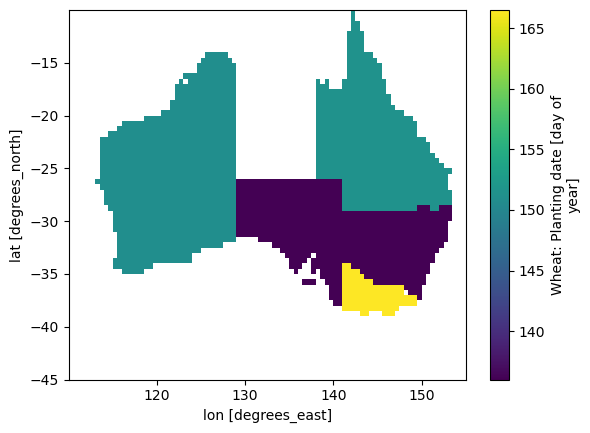

In [3]:
aus_crop_calendar.plant.plot()

In [13]:
lat_check = -25.3
lon_check = 146.7
aus_crop_calendar.lon
state_check = aus_crop_calendar.sel(lat=lat_check, lon=lon_check, method='nearest')
print(state_check.plant.values)
print(state_check.harvest.values)

151.5
304.0


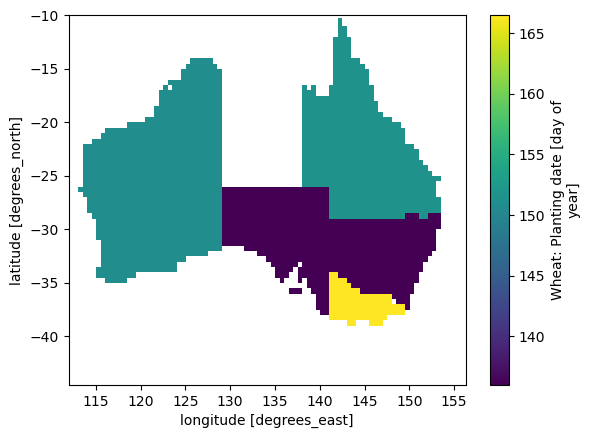

In [48]:
def regrid_to_agcd(da, year):
    agcd_filepath = '/g/data/zv2/agcd/v1-0-1/precip/total/r005/01day/'
    agcd_data = xr.open_dataset(agcd_filepath + f'agcd_v1-0-1_precip_total_r005_daily_{year}.nc')
    max_lat = max(da.lat.max(), agcd_data.lat.max())
    min_lat = min(da.lat.min(), agcd_data.lat.min())
    max_lon = max(da.lon.max(), agcd_data.lon.max())
    min_lon = min(da.lon.min(), agcd_data.lon.min())

    da = da.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    agcd_data = agcd_data.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    da = da.assign_coords(time=agcd_data.time)
    
    da_regridded = da.interp_like(agcd_data, method='nearest')
    return da_regridded

aus_flipped = aus_crop_calendar.sortby('lat')
regrid_da = regrid_to_agcd(aus_flipped, 2000)
regrid_da.plant.plot()

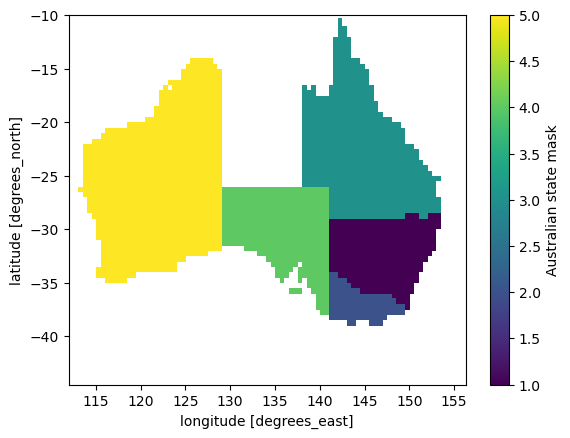

In [21]:
mask_path = '/g/data/w97/mg5624/ABS_project/masks/state_mask.nc'
mask = xr.open_dataarray(mask_path)
mask.plot()

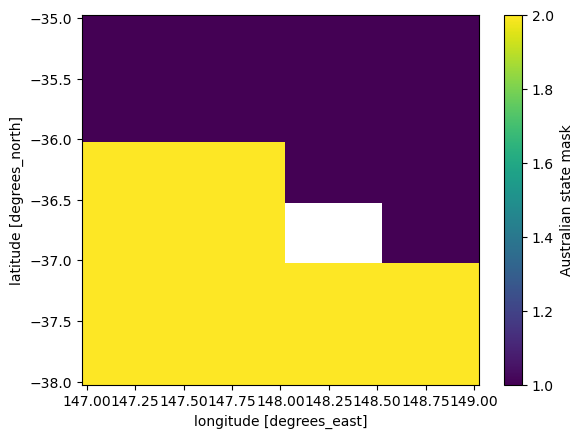

In [ ]:
mask.sel(lat=slice(-38, -35), lon=slice(147, 149)).plot()
mask

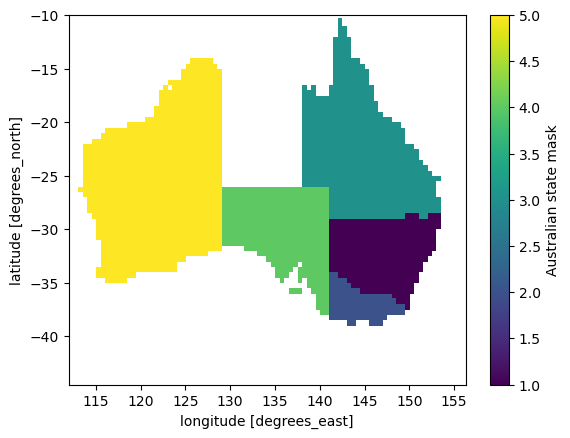

In [18]:
nan_points = (
    (mask.lat >= -37) & (mask.lat <= -36.5) &
    (mask.lon >= 148) & (mask.lon <= 148.5)
)

mask = mask.where(~nan_points, 2)
mask.plot()

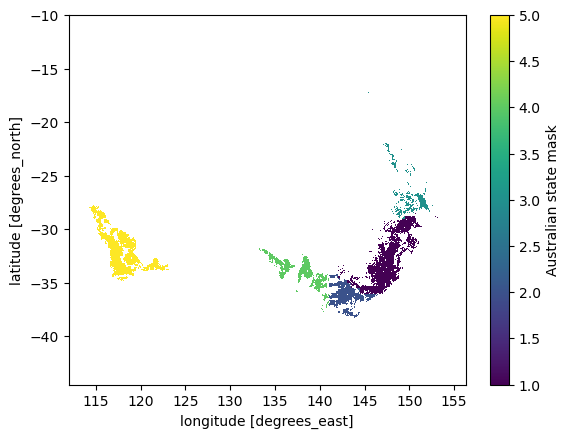

In [56]:
wheatbelt_mask = xr.open_dataarray('/g/data/w97/mg5624/ABS_project/masks/wheatbelt_mask.nc')
state_mask = xr.open_dataarray('/g/data/w97/mg5624/ABS_project/masks/state_mask.nc')
state_wheat_mask = state_mask.where(wheatbelt_mask == 1)
state_wheat_mask.plot()


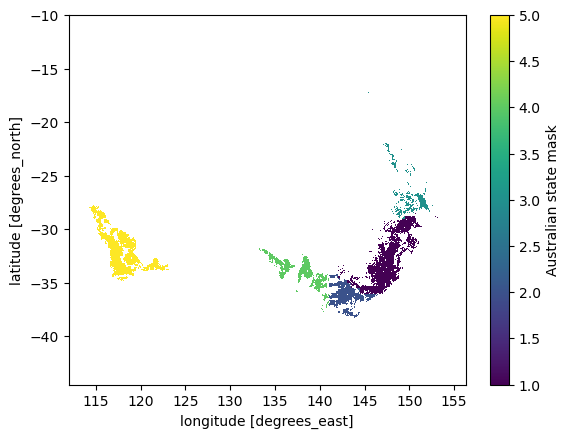

In [57]:
wheta_mask = xr.open_dataarray('/g/data/w97/mg5624/ABS_project/masks/state_wheat_mask.nc')
wheta_mask.plot()

In [20]:
mask.to_netcdf('/g/data/w97/mg5624/ABS_project/masks/state_mask.nc')

In [25]:
path = '/g/data/w97/mg5624/ABS_project/extremes/FY_aggregated/'
file = 'consecutive_dry_days_FY_agg_1950-2021.nc'

ds = xr.open_dataset(path + file)
ds

<xarray.Dataset> Size: 695MB
Dimensions:                                 (time: 71, lat: 691, lon: 886)
Coordinates:
  * time                                    (time) int64 568B 1951 1952 ... 2021
  * lat                                     (lat) float32 3kB -44.5 ... -10.0
  * lon                                     (lon) float32 4kB 112.0 ... 156.2
Data variables:
    growing_seas_consecutive_dry_days_max   (time, lat, lon) int32 174MB ...
    planting_seas_consecutive_dry_days_max  (time, lat, lon) int32 174MB ...
    mid_seas_consecutive_dry_days_max       (time, lat, lon) int32 174MB ...
    harvest_seas_consecutive_dry_days_max   (time, lat, lon) int32 174MB ...

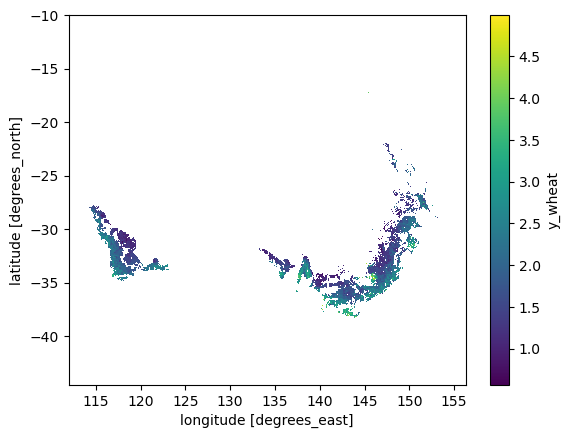

In [30]:
wheat_belt_path = '/g/data/w97/mg5624/ABS_project/ag_data/'
wheatbelt = xr.open_dataset(wheat_belt_path + 'avg_yield.nc').y_wheat
wheatbelt.plot()

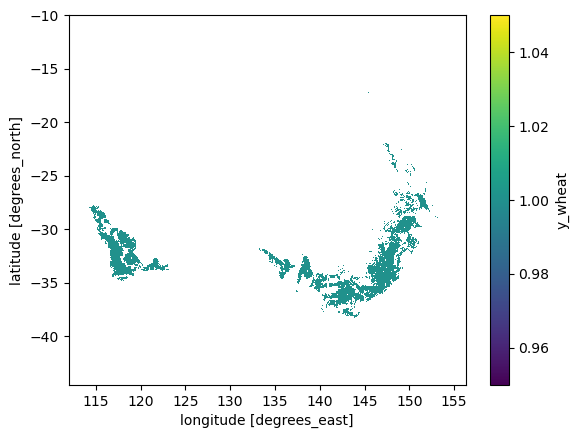

In [35]:
wheatbelt_mask = wheatbelt.where(wheatbelt.isnull(), 1)
wheatbelt_mask.plot()

In [36]:
wheatbelt_mask.to_netcdf('/g/data/w97/mg5624/ABS_project/masks/wheatbelt_mask.nc')

In [41]:
wheatbelt_mask

<xarray.DataArray 'y_wheat' (lat: 691, lon: 886)> Size: 5MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(691, 886))
Coordinates:
  * lat      (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2

In [ ]:
crop_calendar_wheat = crop_calendar.where(wheatbelt_mask == 1)
crop_calendar_wheat.plant.plot()

ValueError: Cannot apply_along_axis when any iteration dimensions are 0

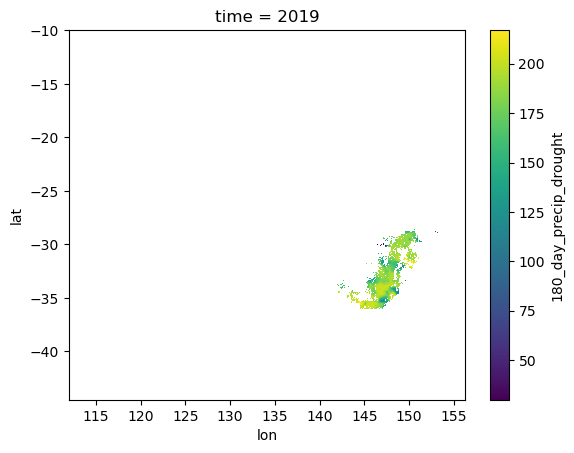

In [65]:
pred_path = '/g/data/w97/mg5624/ABS_project/predictors_per_state/'
NSW_file = 'NSW_predictors.nc'
NSW_pred = xr.open_dataset(pred_path + NSW_file)
NSW_pred['180_day_precip_drought'].sel(time=2019).plot()
